## Analyzing Multiple Completed Simulations
Dan Chen, Summer 2026

### Imports

In [5]:
# === IMPORTS ===
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as patches
import matplotlib.patheffects as path_effects

from astropy import units as u
from pathlib import Path
from collections import defaultdict
from fractions import Fraction
from functools import reduce

import mmr_id
import rebound_sims as reb_sims
from param_grid_plots import plot_param_grid_multi, plot_param_grid_map
from accretion import *

import sys
import warnings
warnings.filterwarnings('ignore')

from helpers import *
plot_prettier(fontsize=12, fig_dpi=150)

# === UNIT CONVERSIONS ===
AU = u.AU.to(u.cm)    
G = 4*np.pi**2 # in yr, AU, Msun
Msun = u.Msun.to(u.g) 
yr = u.yr.to(u.s)    
r_earth = u.earthRad.to(u.AU)
m_earth = u.Mearth.to(u.Msun)
r_sun = u.Rsun.to(u.AU) 

### Obtain simulation summary outcomes (survival, resonance, libration, accretion)

In [3]:
# First-order resonance classes (up to 7:6)
def classify_resonance(P_ratio, librates):
    """Classify first-order resonances of simulations up to 7:6. 
    If planets are not librating, the result will be "not in resonance".
    If planets are in higher-order or higher-index resonance, the result
    will be "other".


    Args:
        P_ratio (float): (Assigned) period ratio.
        librates (bool): Whether resonant angle librates.

    Returns:
        Classification of the resonance.
    """    


    if not librates or np.isnan(P_ratio):
        return "not in resonance"

    resonances = {
        "2:1": 2/1,
        "3:2": 3/2,
        "4:3": 4/3,
        "5:4": 5/4,
        "6:5": 6/5,
        "7:6": 7/6
    }

    for name, ratio in resonances.items():
        if P_ratio == ratio:
            return name

    return "other"

# P ratios, libration, and Delta between planets
def get_planet_outcomes(dataset_id, sim_ids, pomega='mixed', amp_threshold=90):
    rows = []
    base_dir = Path.cwd()
    for sim_id in sim_ids:
        file_path = base_dir.parent / f"sim_results/dataset{dataset_id}" / f"sim{sim_id}.h5"
        
        try:
            saved_sim = reb_sims.load_simulation_run(file_path)
        except FileNotFoundError:
            continue

        sim_data, metadata = saved_sim
        
        # Check planet survival
        alive_planets = []
        for name in ['planet b', 'planet c', 'planet d'][:metadata['num_pl']]:
            if not np.isnan(sim_data[name]['a'].iloc[-1]):
                alive_planets.append(name)

        # Check both pairs if all planets are alive
        if len(alive_planets) == 3:
            c = alive_planets[1]; d = alive_planets[2]
            
            # Get P_ratios by direct division
            true_outer_P_ratio = sim_data[d]['P'].iloc[-1]/sim_data[c]['P'].iloc[-1]
            
            # Swap planets if inner became outer
            if true_outer_P_ratio < 1:
                c, d = d, c
                true_outer_P_ratio = 1/true_outer_P_ratio
            
            # Check Delta (find p, q such that Delta is closest to 0)
            outer_best = mmr_id.find_best_twoBR_pq(metadata['m_star'], sim_data[c], sim_data[d])
            outer_P_ratio = outer_best[0]/outer_best[1]
            outer_Delta = true_outer_P_ratio/outer_P_ratio - 1
            
            # Check libration of 2BR angle
            outer_librates = (mmr_id.check_resonance(metadata['m_star'], sim_data[c], sim_data[d], pomega=pomega, N=25, amp_threshold=amp_threshold) != (0,0))
        
        else:
            outer_P_ratio = np.nan
            true_outer_P_ratio = np.nan
            outer_Delta = np.nan
            outer_librates = False
        
        # Check ratio of remaining pair, call it inner pair
        if len(alive_planets) >=2:
            b = alive_planets[0]; c = alive_planets[1] # this will be the right pair regardless
                
            # Get P_ratios by direct division
            true_inner_P_ratio = sim_data[c]['P'].iloc[-1]/sim_data[b]['P'].iloc[-1]
            
            # Swap planets if inner became outer
            if true_inner_P_ratio < 1:
                b, c = c, b
                true_inner_P_ratio = 1/true_inner_P_ratio
                
            # Check Delta (find p, q such that Delta is closest to 0)
            inner_best = mmr_id.find_best_twoBR_pq(metadata['m_star'], sim_data[b], sim_data[c])
            inner_P_ratio = inner_best[0]/inner_best[1]
            inner_Delta = true_inner_P_ratio/inner_P_ratio - 1
            
            # Check libration of 2BR angle
            inner_librates = (mmr_id.check_resonance(metadata['m_star'], sim_data[b], sim_data[c], pomega=pomega, amp_threshold=amp_threshold) != (0,0))

        else:
            inner_P_ratio = np.nan
            true_inner_P_ratio = np.nan
            inner_Delta = np.nan
            inner_librates = False
        
        if len(alive_planets) >= 1:
            m_pl = metadata['m_vals'][0]
            a = 0.65
            P = a**(3/2) # for M = 1
            Sigma = metadata['Sigma_1au']*(AU**2 / Msun) * a**-metadata['alpha']
            h = metadata['h_1au'] * a**metadata['beta']
            tau_a = 1/(2.7+1.1*metadata['alpha']) / m_pl / (Sigma * a**2) * h**2 / (2*np.pi / P) # at 0.65 AU
            log_tau_Omega = np.log10(tau_a * 2*np.pi / (a**(3/2))) # at 0.65 AU
            
            chi_a = 1 / (2.7 + 1.1 * metadata['alpha'])
            chi_e = 1 / 0.780
            log_K2 = np.log10(chi_a/chi_e * h**-2) # for inner ptsml and outer planet
        else:
            tau_a = np.nan
            log_tau_Omega = np.nan
            log_K2 = np.nan

        # Create df to store data
        Sigma_1au = metadata['Sigma_1au']
        h_1au = metadata['h_1au']
        
        rows.append({
            "sim_id": sim_id,
            "Sigma_1au": Sigma_1au,
            "h_1au": h_1au,
            "alive_planets": alive_planets,
            "inner_P_ratio": inner_P_ratio,
            "outer_P_ratio": outer_P_ratio,
            "true_inner_P_ratio": round(true_inner_P_ratio, 3),
            "true_outer_P_ratio": round(true_outer_P_ratio, 3),
            "inner_P_Delta (%)": round(inner_Delta*100, 1),
            "outer_P_Delta (%)": round(outer_Delta*100, 1),
            "inner_librates": inner_librates,
            "outer_librates": outer_librates,
            "inner_res_class": classify_resonance(inner_P_ratio, inner_librates),
            "outer_res_class": classify_resonance(outer_P_ratio, outer_librates),
            "pl_survived": len(alive_planets),
            "tau_a (kyr)": tau_a/1000,
            "log_tau_Omega": log_tau_Omega,
            "log_K2": log_K2
        })
        
    outcomes = pd.DataFrame(rows)
    return outcomes

# Sigma_1au, h_1au, log_tau_Omega, log_K2
def disk_params(dataset_id, sim_ids):
    rows = []
    base_dir = Path.cwd()
    for sim_id in sim_ids:
        file_path = base_dir.parent / f"sim_results/dataset{dataset_id}" / f"sim{sim_id}.h5"
        
        try:
            saved_sim = reb_sims.load_simulation_run(file_path)
        except FileNotFoundError:
            continue

        sim_data, metadata = saved_sim
        
        # Get tau_a_Omega and K2
        m_pl = metadata['m_vals'][0]
        m_em = metadata['m_em'] * m_earth
        a1 = 0.5 # middle of disk
        P1 = a1**(3/2) # for M = 1
        P2 = P1#*2 # or whatever ratio
        a2 = P2**(2/3)
        
        Sigma1 = metadata['Sigma_1au']*(AU**2 / Msun) * a1**-metadata['alpha']
        h1 = metadata['h_1au'] * a1**metadata['beta']
        Sigma2 = metadata['Sigma_1au']*(AU**2 / Msun) * a2**-metadata['alpha']
        h2 = metadata['h_1au'] * a2**metadata['beta']

        tau_a1 = 1/(2.7+1.1*metadata['alpha']) / m_em / (Sigma1 * a1**2) * h1**2 / (2*np.pi / P1) 
        tau_a2 = 1/(2.7+1.1*metadata['alpha']) / m_pl / (Sigma2 * a2**2) * h2**2 / (2*np.pi / P2) 
        tau_a = (tau_a2**(-1)-tau_a1**(-1))**(-1)
        
        log_tau_Omega = np.log10(tau_a * 2*np.pi / (a1**(3/2))) 
        
        chi_a = 1 / (2.7 + 1.1 * metadata['alpha'])
        chi_e = 1 / 0.780
        tau_e2 = chi_e/chi_a * h2**2 * tau_a2
        log_K2 = np.log10(tau_a / tau_e2)
        
        rows.append({
            "sim_id": sim_id,
            "Sigma_1au": metadata['Sigma_1au'],
            "h_1au": metadata['h_1au'],
            "tau_a (kyr)": tau_a/1000,
            "log_tau_Omega": round(log_tau_Omega, 2), # prevent errors in plotting
            "log_K2": round(log_K2, 2)
        })
    
    outcomes = pd.DataFrame(rows)
    return outcomes
        
# P ratio, libration, and Delta between one planet and one embryo (unused)
def pl_em_res(dataset_id, sim_ids, pomega='mixed', amp_threshold=90, snapshot=-1):
    rows = []
    base_dir = Path.cwd()
    for sim_id in sim_ids:
        file_path = base_dir.parent / f"sim_results/dataset{dataset_id}" / f"sim{sim_id}.h5"
        
        try:
            saved_sim = reb_sims.load_simulation_run(file_path)
        except FileNotFoundError:
            continue

        sim_data, metadata = saved_sim

        # find alive embryos
        alive_embryos = []
        for name in [f"embryo {i}" for i in range(metadata['num_em'])]:
            if not np.isnan(sim_data[name]['a'].iloc[snapshot]):
                alive_embryos.append(name)
                
        if len(alive_embryos) >= 1:
            for embryo_name in alive_embryos:
                b = embryo_name
                c = 'planet c'

            # Get P_ratios by direct division
            true_inner_P_ratio = sim_data[c]['P'].iloc[snapshot]/sim_data[b]['P'].iloc[snapshot]
            
            # Don't consider embryos outside of planet c's orbit
            if true_inner_P_ratio < 1:
                continue
                    
            # Check libration of 2BR angle
            inner_librates = (mmr_id.check_resonance(metadata['m_star'], sim_data[b], sim_data[c], pomega=pomega, amp_threshold=amp_threshold) != (0,0))
            if inner_librates:
                resonant_embryos += 1
        else:
            resonant_embryos = 0
        
        rows.append({
            "sim_id": sim_id,
            "resonant_embryos": resonant_embryos     
        })
        
    outcomes = pd.DataFrame(rows)
    return outcomes

# Find embryos AND planetesimals between b and c; detect resonance with inner planet
def embryos_between_planets(dataset_id, sim_ids, inner='planet b', outer='planet c', N=15, amp_threshold=90, snapshot=-1):
    rows = []
    base_dir = Path.cwd()
    for sim_id in sim_ids:
        file_path = base_dir.parent / f"sim_results/dataset{dataset_id}" / f"sim{sim_id}.h5"
        
        try:
            saved_sim = reb_sims.load_simulation_run(file_path)
        except FileNotFoundError:
            continue

        sim_data, metadata = saved_sim
    
        a_inner = sim_data[inner]["a"].iloc[-1]
        a_outer = sim_data[outer]["a"].iloc[-1]
        
        inside_found = 0
        inside_names = []

        for name, df in sim_data.items():
            if not (
                name.startswith("embryo")
                or name.startswith("ptsml")
            ):
                continue

            a_em = df["a"].iloc[snapshot]

            if np.isnan(a_em):
                continue

            if a_inner*1.01 <= a_em <= a_outer*0.99:  # 1% buffer to avoid edge cases (co-orbital embryos)
                inside_found += 1
                inside_names.append(name)
        
        b_resonant_embryos = 0
        b_resonant_names = []
        c_resonant_embryos = 0
        c_resonant_names = []
        
        if inside_found >= 1:
            for embryo_name in inside_names:
                
                # Check libration of 2BR angle of inner pair
                inner_librates = (mmr_id.check_resonance(metadata['m_star'], sim_data[inner], sim_data[embryo_name], N=N, pomega='mixed', amp_threshold=amp_threshold) != (0,0))
                if inner_librates:
                    b_resonant_names.append(embryo_name)
                    b_resonant_embryos += 1
                
                # Check libration of 2BR angle of outer pair
                outer_librates = (mmr_id.check_resonance(metadata['m_star'], sim_data[embryo_name], sim_data[outer], N=N, pomega='mixed', amp_threshold=amp_threshold) != (0,0))
                if outer_librates:
                    c_resonant_names.append(embryo_name)
                    c_resonant_embryos += 1
        
        rows.append({
            "sim_id": sim_id,
            "embryos_inside": inside_found,
            "inside_names": inside_names,
            "b_resonant_embryos": b_resonant_embryos,
            "b_resonant_names": b_resonant_names,
            "c_resonant_embryos": c_resonant_embryos,
            "c_resonant_names": c_resonant_names,
        })
    
    outcomes = pd.DataFrame(rows)
    return outcomes

# Embryo mass
def additional_params(dataset_id, sim_ids):
    rows = []
    base_dir = Path.cwd()
    for sim_id in sim_ids:
        file_path = base_dir.parent / f"sim_results/dataset{dataset_id}" / f"sim{sim_id}.h5"
        
        try:
            saved_sim = reb_sims.load_simulation_run(file_path)
        except FileNotFoundError:
            continue

        sim_data, metadata = saved_sim
        
        rows.append({
            "sim_id": sim_id,
            "m_em": metadata['m_em']
        })
    
    outcomes = pd.DataFrame(rows)
    return outcomes

# Planetesimal (and embryo) accretion data
def get_ptsml_outcomes(dataset_id, sim_ids, snapshot=None):
    rows = []
    
    for sim_id in sim_ids:
        base_dir = Path.cwd()
        file_path = base_dir.parent / f"sim_results/dataset{dataset_id}" / f"sim{sim_id}.h5"
        
        try:
            saved_sim = reb_sims.load_simulation_run(file_path)
        except FileNotFoundError:
            # print(f"Sim {sim_id} not found")
            continue
        
        sim_data, metadata = saved_sim
        
        # Get survival fraction
        if snapshot:
            snapshot_time = sim_data["planet b"]["time"].iloc[snapshot] / 1000  # kyr
        else:
            snapshot_time = None
        # print(f"Processing Sim {sim_id}", end='\r', flush=True)
        
        if not metadata['collision_log']: # no collisions occurred
            em_surv_rate, ptsml_surv_rate, ejec_rate = 100, 100, 0
        else:
            collision_df = get_collision_log(metadata, snapshot_time)
            fates_df = get_particle_fates(metadata, snapshot_time)
            summary = summarize_accretion(metadata, collision_df, fates_df)
            em_surv_rate = summary['embryo %']['Survived']
            ptsml_surv_rate = summary['ptsml %']['Survived']
            
            # Get ejection fraction (both embryos and planetesimals; ejected due to being removed from sim)
            ejec_rate = fates_df['outcome'].str.contains('ejected').sum()/len(fates_df)

        # Find median of semimajor axes of embryos
        em_a_finals = [sim_data[f'embryo {i}']["a"].iloc[-1] for i in range(metadata['num_em'])]
        em_a_med = np.nanmedian(em_a_finals)
        
        # Find median e of embryos
        em_e_finals = [sim_data[f'embryo {i}']["e"].iloc[-1] for i in range(metadata['num_em'])]
        em_e_med = np.nanmedian(em_e_finals)

        # Find median of semimajor axes of ptsmls
        ptsml_a_finals = [sim_data[f'ptsml {i}']["a"].iloc[-1] for i in range(metadata['num_ptsml'])]
        ptsml_a_med = np.nanmedian(ptsml_a_finals)
        
        # Find median e of ptsmls
        ptsml_e_finals = [sim_data[f'ptsml {i}']["e"].iloc[-1] for i in range(metadata['num_ptsml'])]
        ptsml_e_med = np.nanmedian(ptsml_e_finals)

        rows.append({
            "sim_id": sim_id,
            "em_surv_rate (%)": em_surv_rate,
            "ptsml_surv_rate (%)": ptsml_surv_rate,
            "ejec_rate (%)": ejec_rate,
            "ptsml_a_median": ptsml_a_med,
            "ptsml_e_median": ptsml_e_med,
            "em_a_median": em_a_med,
            "em_e_median": em_e_med,
        })
        
    outcomes = pd.DataFrame(rows)
    return outcomes

In [8]:
dataset_id = 2
sim_ids = list(range(10800))
snapshot = -1

existing_outcomes = pd.read_hdf(f"dfs/outcomes{dataset_id}_{snapshot}.h5", key="df") # Load data
missing = [sim_id for sim_id in range(10800) if not (Path.cwd().parent / f"sim_results/dataset{dataset_id}" / f"sim{sim_id}.h5").exists()]
new_sim_ids = [sim_id for sim_id in sim_ids if sim_id not in existing_outcomes['sim_id'].values and sim_id not in missing]
sim_ids = new_sim_ids

if len(sim_ids) == 0:
    print("No new sims to analyze")
    sys.exit()
    
print(len(sim_ids), "new sims to analyze")

disk_df = disk_params(dataset_id=dataset_id, sim_ids=sim_ids)
print("Disk df collected")
embryo_df = embryos_between_planets(dataset_id=dataset_id, sim_ids=sim_ids, inner='planet b', outer='planet c', amp_threshold=120, snapshot=snapshot)
print("Embryos df collected")
additional_df = additional_params(dataset_id=dataset_id, sim_ids=sim_ids)
print("Additional df collected")
accretion_df = get_ptsml_outcomes(dataset_id=dataset_id, sim_ids=sim_ids, snapshot=snapshot)
print("Accretion df collected")

merged_outcomes = reduce(lambda left, right: pd.merge(left, right, on='sim_id', how='outer'), [disk_df, embryo_df, additional_df, accretion_df])

# Drop unneeded columns
merged_outcomes = merged_outcomes.drop(columns=[
                                                'ptsml_surv_rate (%)', 
                                                'ejec_rate (%)', 
                                                'ptsml_a_median', 
                                                'ptsml_e_median'
                                            ])

merged_outcomes = pd.concat([existing_outcomes, merged_outcomes], ignore_index=True) # Merge with existing outcomes
merged_outcomes.to_hdf(f"dfs/outcomes{dataset_id}_{snapshot}.h5", key="df", mode="w") # Save to disk
print(len(merged_outcomes), "total sims analyzed")

No new sims to analyze


SystemExit: 

In [10]:
dataset_id = 2
snapshot = -1
outcomes = pd.read_hdf(f"dfs/outcomes{dataset_id}_{snapshot}.h5", key="df") # Load data
mask = (outcomes['m_em'].isin([1e-6, 1e-4, 1e-2, 1e-1]))
# mask = (outcomes['m_em'] == 1e-1) 
# outcomes[mask][outcomes['embryos_inside'] != 0][outcomes['Sigma_1au'] > 800][outcomes['Sigma_1au'] < 5000]

### Plot parameter grid (2 parameters)

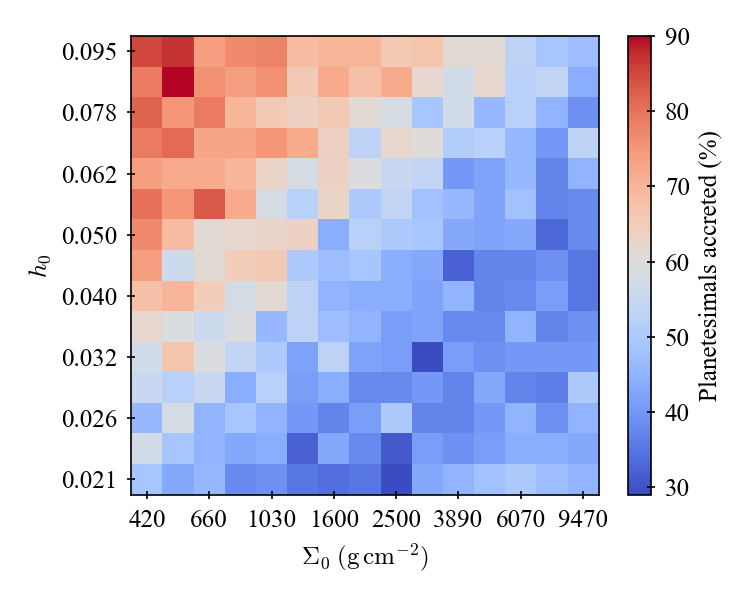

In [5]:
%matplotlib widget

dataset_id = 7
snapshot = -1
outcomes = pd.read_hdf(f"dfs/planet_outcomes{dataset_id}.h5", key="df") # Load data
ptsml_outcomes = pd.read_hdf(f"dfs/ptsml_outcomes{dataset_id}.h5", key="df") # Load data
outcomes = pd.merge(outcomes, ptsml_outcomes, on='sim_id', how='outer')
outcomes['accreted (%)'] = 100 - outcomes['surv_rate (%)']

# plot_param_grid_map(outcomes, "pl_survived", "Number of planets remaining", vmin=1, show_text=False, show_box=False, black_threshold=3)
# plot_param_grid_map(outcomes, "true_inner_P_ratio", r"Inner pair period ratio ($P_c/P_b$)", x_col="log_tau_Omega", y_col="log_K2", vmin=1, vmax=2, show_text=True, show_libration=False, show_Delta=False, show_box=False, black_threshold=1.6, log_cmap=True)
# plot_param_grid_map(outcomes, "inner_P_ratio", r"Inner pair period ratio ($P_c/P_b$)", vmin=1, vmax=2, show_text=False, show_libration=False, show_Delta=False, show_box=False, black_threshold=1.6, log_cmap=True)
# plot_param_grid_map(outcomes, "inner_P_ratio", r"Inner pair period ratio ($P_c/P_b$)", x_col="log_tau_Omega", y_col="log_K2", nbins=32, vmin=1, vmax=2, show_text=True, show_libration=False, show_Delta=False, show_box=False, black_threshold=1.6, log_cmap=True)
# plot_param_grid_map(outcomes, "outer_P_ratio", r"Outer pair period ratio ($P_d/P_c$)", vmin=1, show_text=False, show_libration=False, show_box=False, black_threshold=1.6, log_cmap=True)
# plot_param_grid_map(outcomes, "tau_a (kyr)", r"$\tau_a$ (kyr)", cmap='coolwarm', log_cmap=True, black_threshold=0)

# plot_param_grid_map(outcomes, "log_tau_Omega", r"$\log \tau_a \Omega$", show_text=True, show_libration=False, show_Delta=False, show_box=False, black_threshold=1.6, log_cmap=True)
# plot_param_grid_map(outcomes, "log_K2", r"$\log K_2$",show_text=True, show_libration=False, show_Delta=False, show_box=False, black_threshold=1.6, log_cmap=True)
# plot_param_grid_map(outcomes, "sim_id", "Sim ID", nbins=32, black_threshold=200)

plot_param_grid_map(outcomes, "accreted (%)", "Planetesimals accreted (%)", cmap='coolwarm', show_text=False, nbins=15, x_tick_step=2, y_tick_step=2)
# plot_param_grid_map(outcomes, "ejec_rate (%)", "Fraction of planetesimals ejected (%)")
# plot_param_grid_map(outcomes, "ptsml a_median", "Median semi-major axis of surviving planetesimals", cmap='BuPu', black_threshold=0)
# plot_param_grid_map(outcomes, "ptsml e_median", "Median eccentricity of surviving planetesimals", cmap='BuPu', black_threshold=0)

### Plot parameter grid (3 parameters)

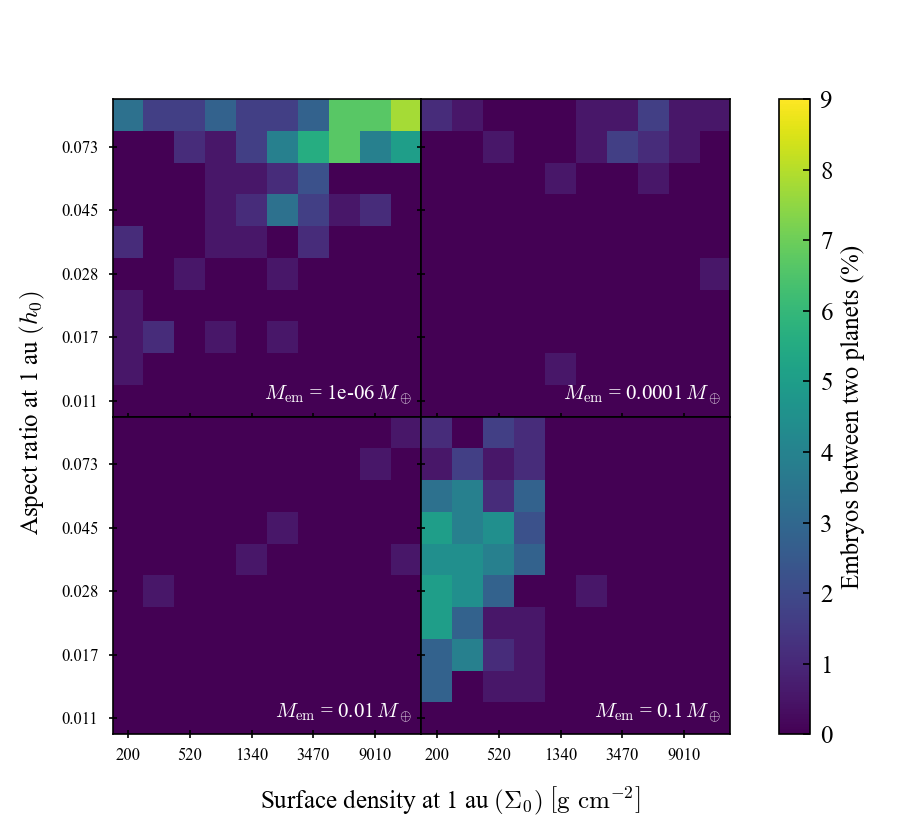

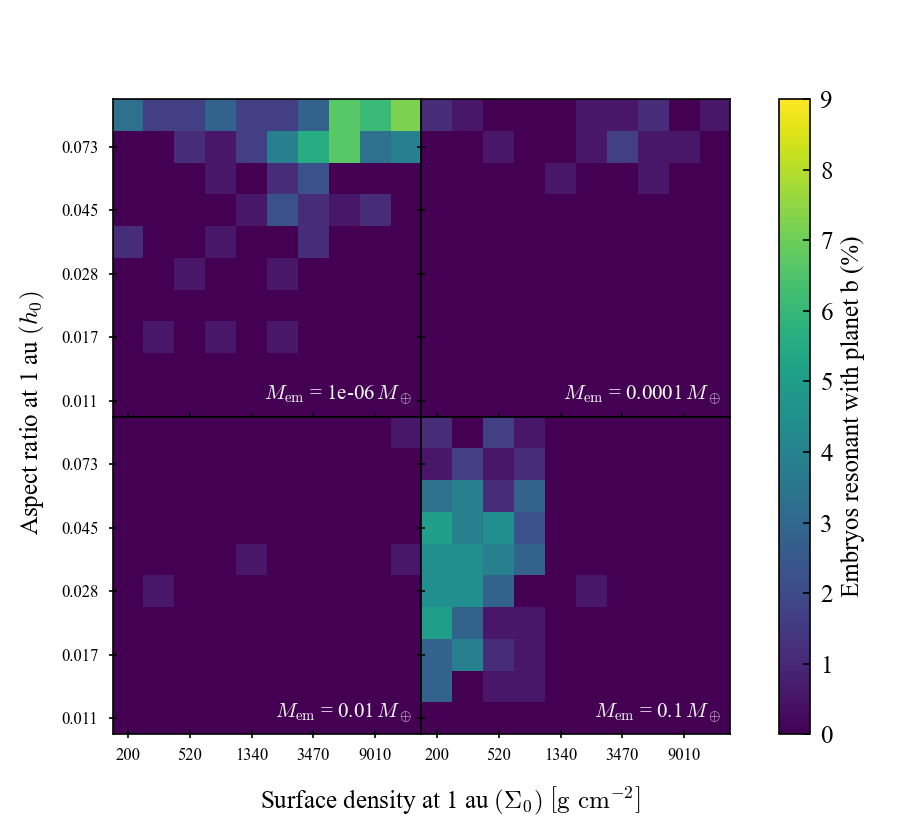

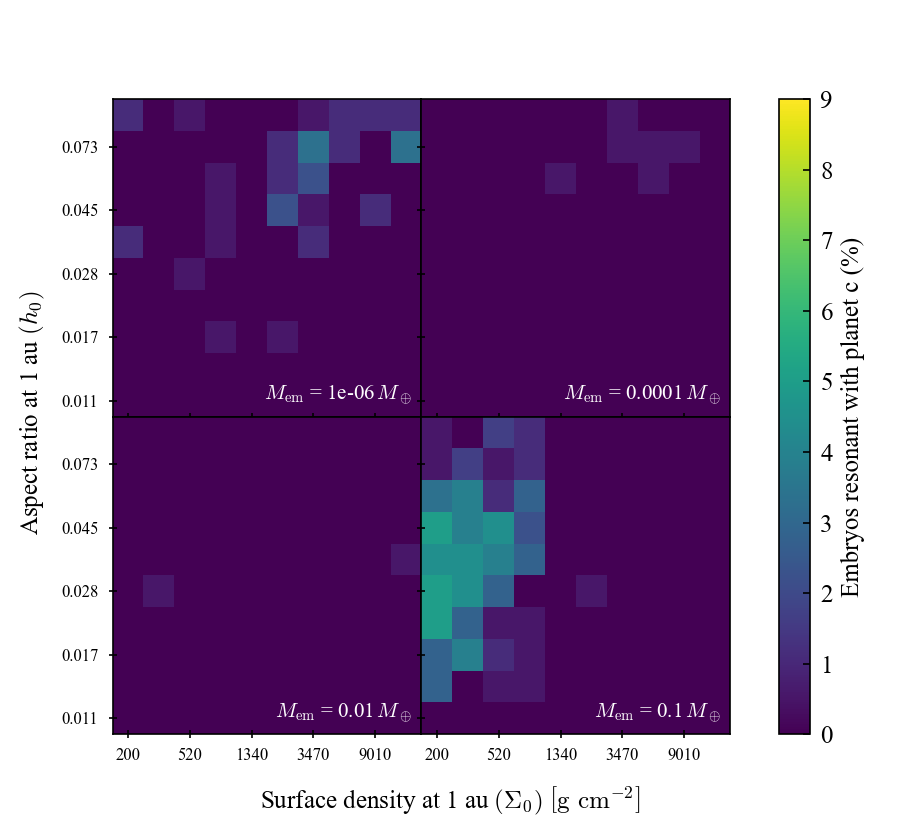

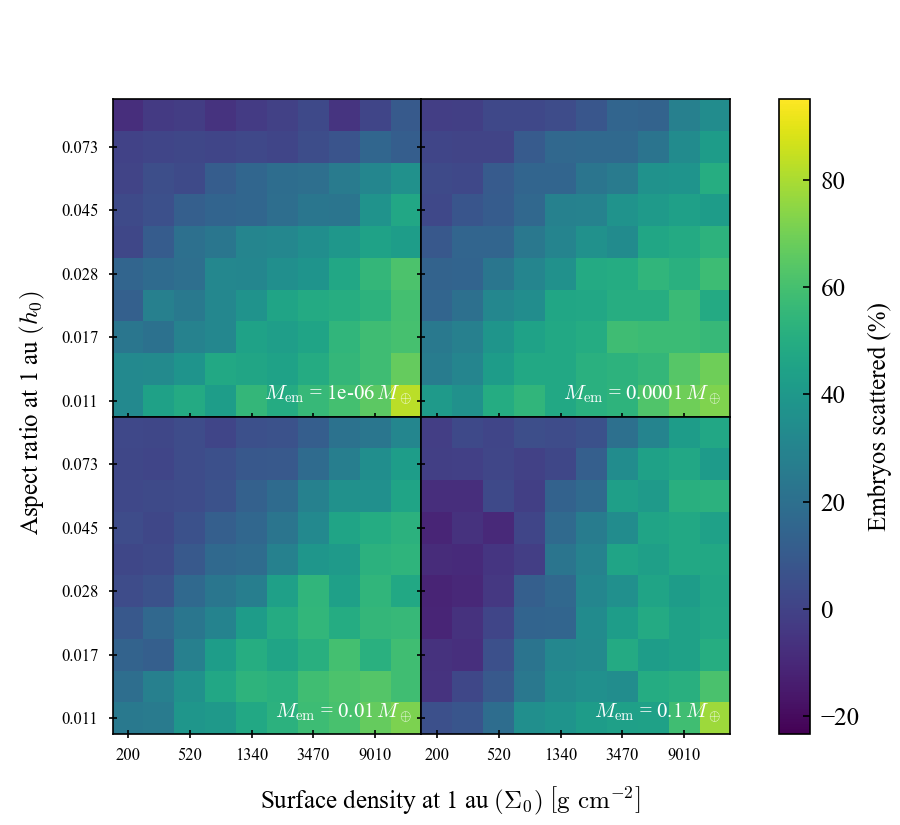

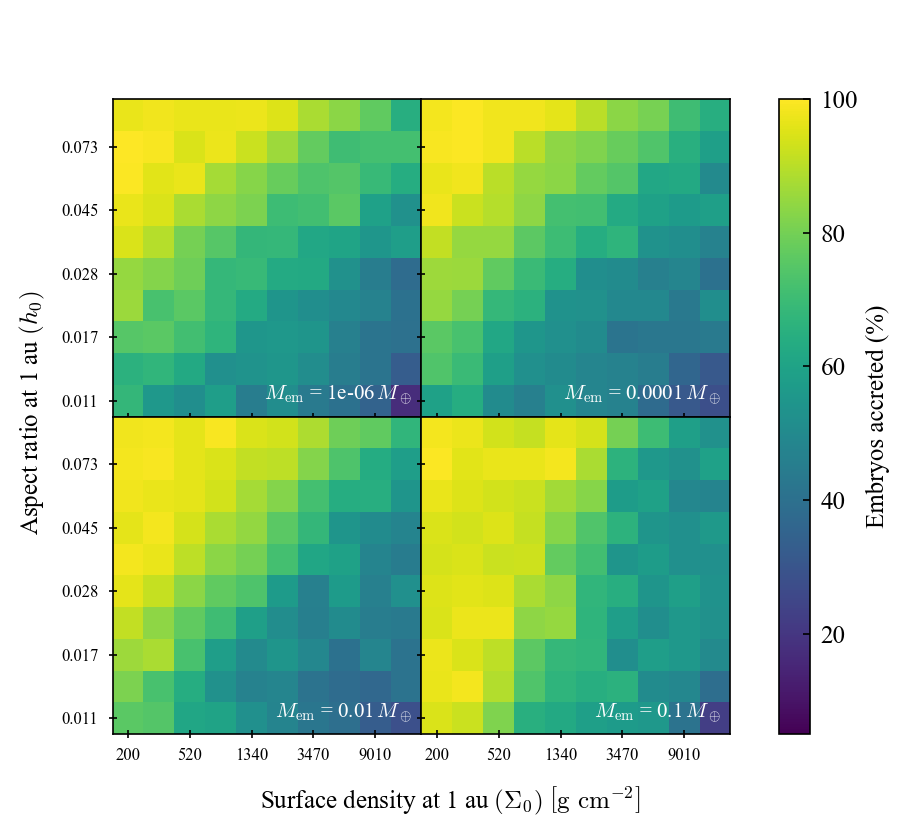

In [16]:
%matplotlib widget
dataset_id = 2
snapshot = -1
outcomes = pd.read_hdf(f"dfs/outcomes{dataset_id}_{snapshot}.h5", key="df")[mask] # Load data

# outcomes = outcomes[outcomes['m_em'] <= 5e-7] # Optional mass filter 
outcomes['embryos_inside (%)'] = 100 * outcomes['embryos_inside'] / 20
outcomes['b_resonant_embryos (%)'] = 100 * outcomes['b_resonant_embryos'] / 20
outcomes['c_resonant_embryos (%)'] = 100 * outcomes['c_resonant_embryos'] / 20
outcomes['scattered (%)'] = outcomes["em_surv_rate (%)"] - 100*outcomes["embryos_inside"]/6
outcomes['accreted (%)'] = 100 - outcomes["em_surv_rate (%)"]

ncols = 2
x_tick_step = 2
y_tick_step = 2

plot_param_grid_multi(outcomes, "embryos_inside (%)", "Embryos between two planets (%)", show_text=False, ncols=ncols, x_tick_step=x_tick_step, y_tick_step=y_tick_step, start_tick_index=0, cmap='viridis', nbins=10, vmax=9)
# plot_param_grid_multi(outcomes, "em_surv_rate (%)", "Total embryos survived (%)", show_text=False, ncols=ncols, x_tick_step=x_tick_step, y_tick_step=y_tick_step)

# plot_param_grid_multi(outcomes, "b_resonant_embryos", "Embryos resonant with planet b", show_text=False, ncols=ncols, x_tick_step=x_tick_step, y_tick_step=y_tick_step, nbins=10, vmax=1.6)
# plot_param_grid_multi(outcomes, "c_resonant_embryos", "Embryos resonant with planet c", show_text=False, ncols=ncols, x_tick_step=x_tick_step, y_tick_step=y_tick_step, nbins=10, vmax=1.6)

plot_param_grid_multi(outcomes, "b_resonant_embryos (%)", "Embryos resonant with planet b (%)", show_text=False, ncols=ncols, x_tick_step=x_tick_step, y_tick_step=y_tick_step, nbins=10, vmax=9)
plot_param_grid_multi(outcomes, "c_resonant_embryos (%)", "Embryos resonant with planet c (%)", show_text=False, ncols=ncols, x_tick_step=x_tick_step, y_tick_step=y_tick_step, nbins=10, vmax=9)

plot_param_grid_multi(outcomes, "scattered (%)", "Embryos scattered (%)", show_text=False, ncols=ncols, x_tick_step=x_tick_step, y_tick_step=y_tick_step, nbins=10)
plot_param_grid_multi(outcomes, "accreted (%)", "Embryos accreted (%)", show_text=False, ncols=ncols, x_tick_step=x_tick_step, y_tick_step=y_tick_step, nbins=10)
# plot_param_grid_multi(outcomes, "sim_id", "Sim ID", ncols=ncols, x_tick_step=x_tick_step, y_tick_step=y_tick_step)

### Plot zoomed-in parameter space with binned samples

In [ ]:
def plot_binned_param_map(outcomes, value_col, label, Sigma_range=None, h_range=None, nbins=10, cmap="viridis", vmin=None, vmax=None, log_cmap=False, black_threshold=None, show_text=True, scatter=True, show_sim_id=False):

    # Parameter space limits
    if Sigma_range is None:
        Sigma_range = (
            outcomes["Sigma_1au"].min(),
            outcomes["Sigma_1au"].max()
        )

    if h_range is None:
        h_range = (
            outcomes["h_1au"].min(),
            outcomes["h_1au"].max()
        )

    # Log-spaced bin edges
    Sigma_edges = np.logspace(
        np.log10(Sigma_range[0]),
        np.log10(Sigma_range[1]),
        nbins + 1
    )

    h_edges = np.logspace(
        np.log10(h_range[0]),
        np.log10(h_range[1]),
        nbins + 1
    )

    # Bin centers for text
    Sigma_centers = np.sqrt(Sigma_edges[:-1] * Sigma_edges[1:])
    h_centers = np.sqrt(h_edges[:-1] * h_edges[1:])

    # Assign simulations to bins

    xbin = np.digitize(
        outcomes["Sigma_1au"],
        Sigma_edges
    ) - 1

    ybin = np.digitize(
        outcomes["h_1au"],
        h_edges
    ) - 1

    outcomes_binned = outcomes.copy()
    outcomes_binned["xbin"] = xbin
    outcomes_binned["ybin"] = ybin

    # Remove points outside edges
    outcomes_binned = outcomes_binned[
        (outcomes_binned["xbin"] >= 0)
        & (outcomes_binned["xbin"] < nbins)
        & (outcomes_binned["ybin"] >= 0)
        & (outcomes_binned["ybin"] < nbins)
    ]

    # Median value in each bin
    median_grid = np.full((nbins, nbins), np.nan)

    for i in range(nbins):
        for j in range(nbins):

            subset = outcomes_binned[
                (outcomes_binned["xbin"] == i)
                & (outcomes_binned["ybin"] == j)
            ]

            if len(subset) > 0:                                                              # Could also use nanmean
                median_grid[i, j] = np.nan if np.isnan(subset[value_col]).mean() > 0.5 else np.nanmedian(subset[value_col])

    # Plot
    fig, ax = plt.subplots(figsize=(5, 4))

    if 'survived' in value_col:
        cmap = mcolors.ListedColormap(["#482173", "#2E6F8E", "#29AF7F"])
        cmap.set_bad("lightgray")
        norm = mcolors.BoundaryNorm([0.5, 1.5, 2.5, 3.5], cmap.N)
    else:
        norm = mcolors.LogNorm(vmin=vmin, vmax=vmax) if log_cmap else None

    mesh = ax.pcolormesh(
        Sigma_edges,
        h_edges,
        median_grid.T,
        cmap=cmap,
        shading="flat",
        norm=norm,
    )

    ax.set_xscale("log")
    ax.set_yscale("log")

    ax.set_xlabel(
        r"$\Sigma_{1\,\rm AU}\;(\mathrm{g\,cm^{-2}})$"
    )
    ax.set_ylabel(
        r"$h_{1\,\rm AU}$"
    )
    
    ax.set_xticks(Sigma_centers)
    ax.set_yticks(h_centers)

    ax.set_xticklabels([f"{x:.0f}" for x in Sigma_centers])
    ax.set_yticklabels([f"{y:.3f}" for y in h_centers])

    ax.minorticks_off()

     # Scatter
    if scatter:
        
        if 'outer' in value_col:
            x_mask = outcomes["outer_P_ratio"].isna()
        elif 'inner' in value_col:
            x_mask = outcomes["inner_P_ratio"].isna()
        else:
            x_mask = np.full(len(outcomes), False)
            
        ax.scatter(
            outcomes.loc[x_mask, "Sigma_1au"],
            outcomes.loc[x_mask, "h_1au"],
            s=2,
            color="red",
            marker="x",
            linewidths=0.5,
            zorder=4,
            alpha=0.8
        )
        
        ax.scatter(
            outcomes.loc[~x_mask, "Sigma_1au"],
            outcomes.loc[~x_mask, "h_1au"],
            s=2,
            alpha=0.5,
            color="k",
            edgecolors="none",
            zorder=3,
            marker="D"
        )

        # Show sim_id's
        if show_sim_id:
            for _, row in outcomes.iterrows():
                ax.annotate(
                    str(int(row["sim_id"])),
                    xy=(row["Sigma_1au"], row["h_1au"]),
                    xytext=(0, -1),
                    textcoords="offset points",
                    ha="center",
                    va="top",
                    fontsize=4,
                    color="k",
                    zorder=4
                )
        
    # Cell text
    ratios = [2/1, 5/3, 3/2, 7/5, 4/3, 5/4, 6/5, 7/6, 8/7, 1]
    if show_text:

        for i, x in enumerate(Sigma_centers):
            for j, y in enumerate(h_centers):

                value = median_grid[i, j]

                if np.isnan(value):
                    continue
                
                color = "white"
                
                if value > black_threshold:
                    color = "k"

                if "ratio" in value_col:
                    frac = Fraction(value).limit_denominator()
                    disp_value = f"{frac.numerator}:{frac.denominator}" if value in ratios else f"{value:.3f}"
                elif "%" in value_col:
                    disp_value = f"{value:.2g}"
                elif "survived" in value_col:
                    disp_value = f"{value:.2g}"
                else:
                    disp_value = f"{value:.2g}"

                text = ax.text(
                    x,
                    y,
                    disp_value,
                    ha="center",
                    va="center",
                    fontsize=6,
                    color=color,
                    zorder=5
                )
                
                text.set_path_effects([
                    path_effects.withStroke(linewidth=0.4, foreground="black")
                ])
                if value > black_threshold:
                    text.set_path_effects([
                        path_effects.withStroke(linewidth=0.4, foreground="white")
                    ])

    cbar = fig.colorbar(mesh, ax=ax)
    cbar.set_label(label)
    
    ax.tick_params(axis='both', direction='inout')
    cbar.ax.tick_params(direction='inout')
    
    if 'ratio' in value_col:
        cbar.set_ticks(ratios, labels=['2:1', '5:3', '3:2', '7:5', '4:3', '5:4', '6:5', '7:6', '8:7', '1:1'])
        cbar.ax.minorticks_off()

    plt.tight_layout()
    plt.show()
 
planet_outcomes = pd.read_hdf("dfs/planet_outcomes8_c.h5", key="df") # Load data
ptsml_outcomes = pd.read_hdf("dfs/ptsml_outcomes8.h5", key="df") # Load data
   
Sigma_range = (10**(454/145), 10**(517/145))
h_range=(10**(-437/290), 10**(-187/145))

plot_binned_param_map(planet_outcomes, 'pl_survived', "Number of planets remaining", Sigma_range, h_range, show_text=True, black_threshold=4)
plot_binned_param_map(planet_outcomes, 'inner_P_ratio', r"Inner pair period ratio ($P_c/P_b$)", Sigma_range, h_range, show_sim_id=False, black_threshold=1.6, vmin=1, vmax=2, log_cmap=True)
plot_binned_param_map(planet_outcomes, 'outer_P_ratio', r"Outer pair period ratio ($P_d/P_c$)", Sigma_range, h_range, show_sim_id=False, black_threshold=1.6, vmin=1, vmax=2, log_cmap=True)
plot_binned_param_map(ptsml_outcomes, 'surv_rate (%)', "Planetesimal survival rate (%)", Sigma_range, h_range, black_threshold=0, cmap='coolwarm')

### Extras

In [18]:
# Code for checking which simulations have not been done
base_dir = Path.cwd()
dataset_id = 2
missing = [
    sim_id
    for sim_id in range(10800)
    if not (base_dir.parent / f"sim_results/dataset{dataset_id}" / f"sim{sim_id}.h5").exists()
]
print(f"{len(missing)} missing")
def format_ranges(nums):
    if not nums:
        return ""

    nums = sorted(nums)
    ranges = []

    start = end = nums[0]

    for n in nums[1:]:
        if n == end + 1:
            end = n
        else:
            if start == end:
                ranges.append(f"{start}")
            else:
                ranges.append(f"{start}-{end}")
            start = end = n

    # Add the last range
    if start == end:
        ranges.append(f"{start}")
    else:
        ranges.append(f"{start}-{end}")

    return ",".join(ranges)
print(format_ranges(missing))

1080 missing
600-602,630-637,660,690-694,720-731,733,750-755,781-786,796,812-839,843-863,876,1500,1502-1504,1560-1561,1590-1598,1600,1602-1603,1605-1622,1650-1656,1658,1661-1665,1667-1727,1740-1746,1748,1771-1799,2430-2431,2460-2468,2490,2520-2524,2550-2562,2580-2591,2610-2614,2640-2669,2671-2699,3300,3330-3335,3338-3339,3345,3390-3392,3420-3455,3480-3484,3510-3563,3571,4260-4261,4290-4299,4320-4321,4350-4354,4356,4380-4393,4410-4427,4440-4446,4471-4535,5160-5163,5220-5221,5250-5265,5267-5291,5310-5314,5340-5369,5371-5399,6120-6126,6150-6155,6180-6181,6210-6219,6240-6250,7080-7088,7091-7092,7094,7098-7127,7140,7171-7177,7180-7181,7185-7187,7189-7199,7950-7955,7980-7988,8010,8040-8047,8071-8081,8850-8855,8880,8910-8913,8918,8924,8928-8929,8932,8934,8936-8938,8940-8963,9750,9780-9788,9810-9819,9871-9875,9877-9878,9900-9935,10530-10532,10560-10583,10590,10620-10624,10633-10634,10637,10641,10646,10650-10691,10710-10716,10740-10769,10771-10799
